In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR

In [2]:
## read the dataset
df = pd.read_csv('bitcoin.csv')

In [3]:
df.head()

,Date,Price
0,5/23/2019,7881.846680
1,5/24/2019,7987.371582
2,5/25/2019,8052.543945
3,5/26/2019,8673.215820
4,5/27/2019,8805.778320


In [5]:
## remove date column
df.drop(columns=['Date'], inplace=True)

In [6]:
df.head()

,Price
0,7881.846680
1,7987.371582
2,8052.543945
3,8673.215820
4,8805.778320


In [7]:
predictionDays = 30
# Create another column shifted 'n'  units up
df['Prediction'] = df[['Price']].shift(-predictionDays)
# show the first 5 rows
df.head()

,Price,Prediction
0,7881.846680,10701.69141
1,7987.371582,10855.37109
2,8052.543945,11011.10254
3,8673.215820,11790.91699
4,8805.778320,13016.23145


In [8]:
df.tail()

,Price,Prediction
362,9729.038086,NaN
363,9522.981445,NaN
364,9081.761719,NaN
365,9182.577148,NaN
366,9180.045898,NaN


In [10]:
# Create the independent data set (X)
x = df.drop(columns=['Prediction']).values

# Remove the last 'n' rows where 'n' is predictionDays
x = x[:-predictionDays]

print(x)

[[ 7881.84668 ]
 [ 7987.371582]
 [ 8052.543945]
 [ 8673.21582 ]
 [ 8805.77832 ]
 [ 8719.961914]
 [ 8659.487305]
 [ 8319.472656]
 [ 8574.501953]
 [ 8564.016602]
 [ 8742.958008]
 [ 8208.995117]
 [ 7707.770996]
 [ 7824.231445]
 [ 7822.023438]
 [ 8043.951172]
 [ 7954.12793 ]
 [ 7688.077148]
 [ 8000.32959 ]
 [ 7927.714355]
 [ 8145.857422]
 [ 8230.923828]
 [ 8693.833008]
 [ 8838.375   ]
 [ 8994.488281]
 [ 9320.352539]
 [ 9081.762695]
 [ 9273.521484]
 [ 9527.160156]
 [10144.55664 ]
 [10701.69141 ]
 [10855.37109 ]
 [11011.10254 ]
 [11790.91699 ]
 [13016.23145 ]
 [11182.80664 ]
 [12407.33203 ]
 [11959.37109 ]
 [10817.15527 ]
 [10583.13477 ]
 [10801.67773 ]
 [11961.26953 ]
 [11215.4375  ]
 [10978.45996 ]
 [11208.55078 ]
 [11450.84668 ]
 [12285.95801 ]
 [12573.8125  ]
 [12156.5127  ]
 [11358.66211 ]
 [11815.98633 ]
 [11392.37891 ]
 [10256.05859 ]
 [10895.08984 ]
 [ 9477.641602]
 [ 9693.802734]
 [10666.48242 ]
 [10530.73242 ]
 [10767.13965 ]
 [10599.10547 ]
 [10343.10645 ]
 [ 9900.767578]
 [ 9811.

In [11]:
# Create the dependent dataset (y)
y = df['Prediction'].to_numpy()

# Remove last 'n' rows
if predictionDays > 0:
    y = y[:-predictionDays]

print(y)

[10701.69141  10855.37109  11011.10254  11790.91699  13016.23145
 11182.80664  12407.33203  11959.37109  10817.15527  10583.13477
 10801.67773  11961.26953  11215.4375   10978.45996  11208.55078
 11450.84668  12285.95801  12573.8125   12156.5127   11358.66211
 11815.98633  11392.37891  10256.05859  10895.08984   9477.641602
  9693.802734 10666.48242  10530.73242  10767.13965  10599.10547
 10343.10645   9900.767578  9811.925781  9911.841797  9870.303711
  9477.677734  9552.860352  9519.145508  9607.423828 10085.62793
 10399.66895  10518.17481  10821.72656  10970.18457  11805.65332
 11478.16895  11941.96875  11966.40723  11862.93652  11354.02441
 11523.5791   11382.61621  10895.83008  10051.7041   10311.5459
 10374.33887  10231.74414  10345.81055  10916.05371  10763.23242
 10138.04981  10131.05566  10407.96484  10159.96094  10138.51758
 10370.82031  10185.5       9754.422852  9510.200195  9598.173828
  9630.664063  9757.970703 10346.76074  10623.54004  10594.49316
 10575.5332   10353.302

In [13]:
# Independent & dependent variables
X = df.drop(columns=['Prediction']).to_numpy()
y = df['Prediction'].to_numpy()

# Remove last predictionDays rows
if predictionDays > 0:
    X = X[:-predictionDays]
    y = y[:-predictionDays]

# Train-test split (Time-series safe)
xtrain, xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Last 'n' rows for future prediction
predictionDays_array = df.drop(columns=['Prediction']).to_numpy()[-predictionDays:]

print(predictionDays_array)

[[7550.900879]
 [7569.936035]
 [7679.867188]
 [7795.601074]
 [7807.058594]
 [8801.038086]
 [8658.553711]
 [8864.766602]
 [8988.59668 ]
 [8897.46875 ]
 [8912.654297]
 [9003.070313]
 [9268.761719]
 [9951.518555]
 [9842.666016]
 [9593.896484]
 [8756.430664]
 [8601.795898]
 [8804.477539]
 [9269.987305]
 [9733.72168 ]
 [9328.197266]
 [9377.013672]
 [9670.739258]
 [9726.575195]
 [9729.038086]
 [9522.981445]
 [9081.761719]
 [9182.577148]
 [9180.045898]]


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

# Create pipeline (Best Practice)
svr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=1000, gamma=0.00001))
])

# Train model
svr_model.fit(xtrain, ytrain)

,steps,"[('scaler', ...), ('svr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,'rbf'
,degree,3
,gamma,1e-05
,coef0,0.0


In [21]:
from sklearn.svm import SVR

svr_rbf = SVR(kernel='rbf', C=1000, gamma=0.00001)
svr_rbf.fit(xtrain, ytrain)

,kernel,'rbf'
,degree,3
,gamma,1e-05
,coef0,0.0
,tol,0.001
,C,1000
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [22]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

ypred = svr_rbf.predict(xtest)

r2 = r2_score(ytest, ypred)
mse = mean_squared_error(ytest, ypred)
rmse = np.sqrt(mse)

print("R2:", r2)
print("RMSE:", rmse)

R2: -1.78750163681421
RMSE: 2144.6362801786704


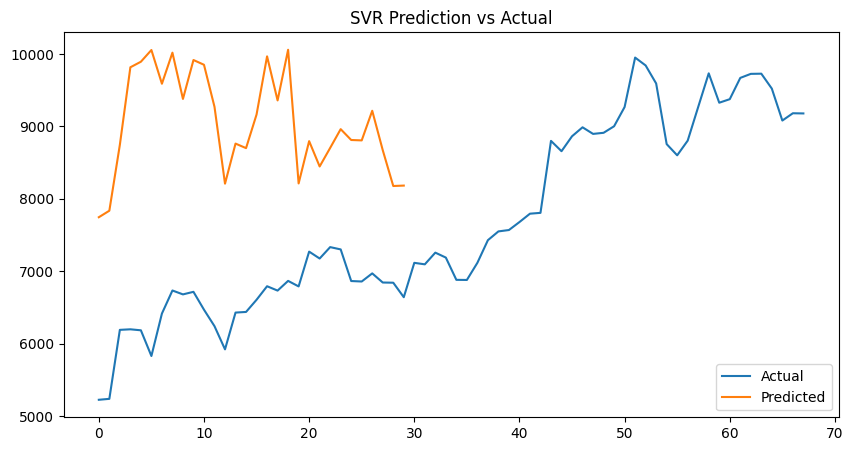

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(ytest, label="Actual")
plt.plot(svm_prediction, label="Predicted")
plt.legend()
plt.title("SVR Prediction vs Actual")
plt.show()

In [33]:
actual_prices = df['Price'].tail(predictionDays).values

import pandas as pd

comparison = pd.DataFrame({
    "Actual_Price": actual_prices,
    "Predicted": svm_prediction
})

print(comparison)

    Actual_Price     Predicted
0    7550.900879   7746.617452
1    7569.936035   7836.556119
2    7679.867188   8746.666475
3    7795.601074   9817.468837
4    7807.058594   9894.112940
5    8801.038086  10056.000992
6    8658.553711   9590.141695
7    8864.766602  10019.253102
8    8988.596680   9380.343962
9    8897.468750   9917.812856
10   8912.654297   9852.164249
11   9003.070313   9271.552129
12   9268.761719   8210.016119
13   9951.518555   8763.596865
14   9842.666016   8700.960574
15   9593.896484   9165.287167
16   8756.430664   9968.535470
17   8601.795898   9359.695234
18   8804.477539  10059.211133
19   9269.987305   8213.471040
20   9733.721680   8797.453995
21   9328.197266   8447.677709
22   9377.013672   8704.089484
23   9670.739258   8963.148122
24   9726.575195   8813.277497
25   9729.038086   8807.709967
26   9522.981445   9216.825042
27   9081.761719   8672.886343
28   9182.577148   8177.919775
29   9180.045898   8183.728024


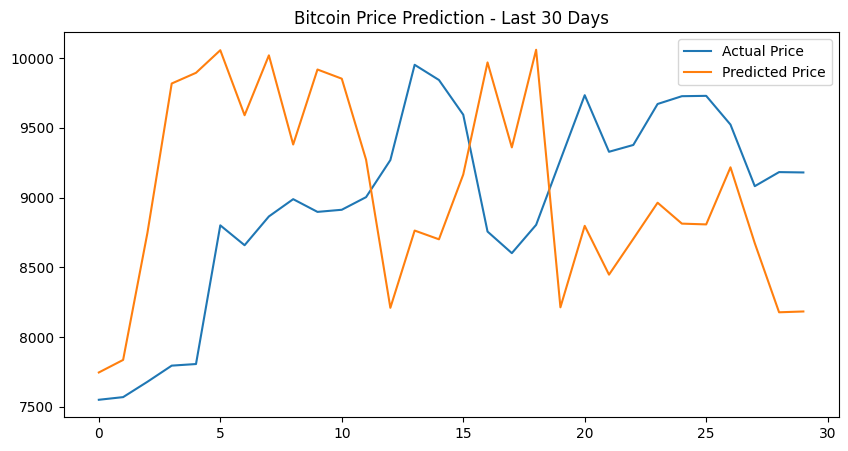

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(actual_prices, label="Actual Price")
plt.plot(svm_prediction, label="Predicted Price")
plt.legend()
plt.title("Bitcoin Price Prediction - Last 30 Days")
plt.show()